In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
import statsmodels.api as sm

In [4]:
df = pd.read_csv('sales.csv')

x = df[['AdvertisingExpenditure','StoreLocation','Competition']]
y = df['SalesRevenue']

In [6]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3)

In [7]:
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [8]:
y_pred = model.predict(x_test)

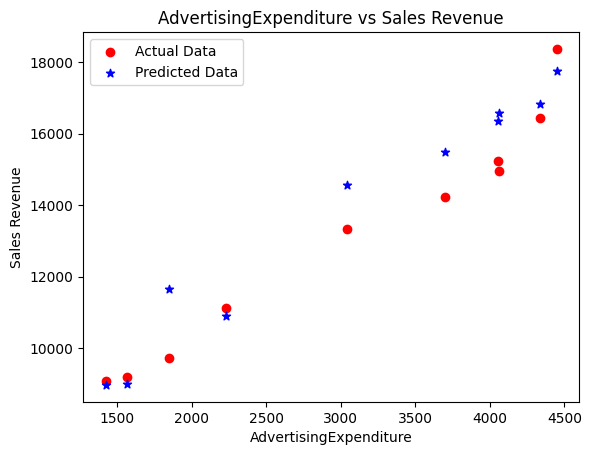

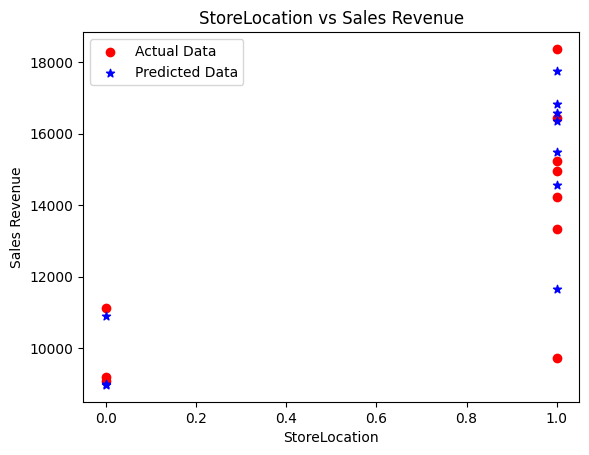

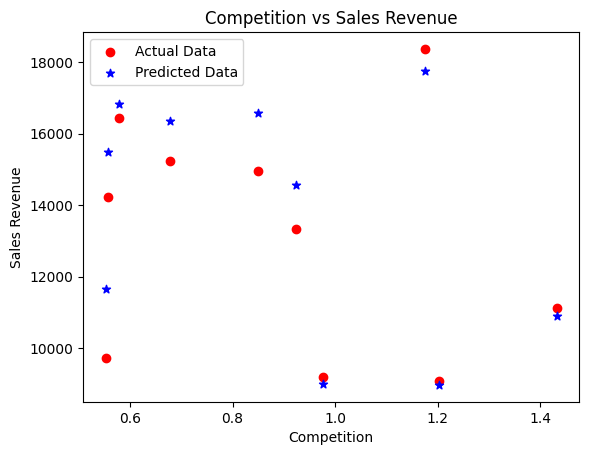

In [18]:
predictors = ['AdvertisingExpenditure','StoreLocation','Competition']

for predictor in predictors:
    plt.scatter(x_test[predictor],y_test,color = 'r',marker='o',label = f"Actual Data")
    plt.scatter(x_test[predictor],y_pred,color = 'b',marker='*',label = "Predicted Data")
    plt.title(f"{predictor} vs Sales Revenue")
    plt.xlabel(predictor)
    plt.ylabel('Sales Revenue')
    plt.legend()
    plt.show()
    

In [11]:
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print(f"Mean Sqaured Error: {mse} and R2 Score: {r2}")

Mean Sqaured Error: 1140853.3109039483 and R2 Score: 0.8798775804947149


In [12]:
x = sm.add_constant(x)

model = sm.OLS(y,x).fit()

In [16]:
for predictor in predictors:
    t_stat = model.tvalues[predictor]
    t_pvalue = model.pvalues[predictor]

    print(f"T-Statistics of {predictor}: {t_stat}")

    if t_pvalue < 0.5:
        print(f"{predictor} is the significant predictor of the Sales Revenue\n")
    else:
        print(f"{predictor} is not the significant predictor of the Sales Revenue\n")

T-Statistics of AdvertisingExpenditure: 12.738460146150285
AdvertisingExpenditure is the significant predictor of the Sales Revenue

T-Statistics of StoreLocation: 4.8991458566344095
StoreLocation is the significant predictor of the Sales Revenue

T-Statistics of Competition: 5.35055785746889
Competition is the significant predictor of the Sales Revenue



In [17]:
f_stat = model.fvalue
f_pvalue = model.f_pvalue

if f_pvalue < 0.2:
    print(f"Overall model and the regression coefficients are statistically significant")
else:
        print(f"Overall model and the regression coefficients are not statistically significant")

Overall model and the regression coefficients are statistically significant
